# Graph Convolutional Networks 

## Normalizing Features with Graph Convolutional Networks

In [1]:
import torch
!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.6.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html

torch.manual_seed(1)
torch.cuda.manual_seed(1)
torch.cuda.manual_seed_all(1)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
import numpy as np
np.random.seed(0)

D = np.array([
    [3, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 2, 0],
    [0, 0, 0, 2]
])

**As a reminder, the inverse of a matrix can be directly calculated using the** `numpy.linalg.inv()` **function**

In [3]:
np.linalg.inv(D)

array([[0.33333333, 0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 0.5       , 0.        ],
       [0.        , 0.        , 0.        , 0.5       ]])

Be aware we have to take into account the information conveyed by the nodes themselves. Therefore, we have to add the selfloops to consider the matrix **A+I**. This is this matrix we want to invert.

In [4]:
np.linalg.inv(D + np.identity(4))

array([[0.25      , 0.        , 0.        , 0.        ],
       [0.        , 0.5       , 0.        , 0.        ],
       [0.        , 0.        , 0.33333333, 0.        ],
       [0.        , 0.        , 0.        , 0.33333333]])

In [5]:
A = np.array([
    [1, 1, 1, 1],
    [1, 1, 0, 0],
    [1, 0, 1, 1],
    [1, 0, 1, 1]
])

print(np.linalg.inv(D + np.identity(4)) @ A)
print()
print(A @ np.linalg.inv(D + np.identity(4)))

[[0.25       0.25       0.25       0.25      ]
 [0.5        0.5        0.         0.        ]
 [0.33333333 0.         0.33333333 0.33333333]
 [0.33333333 0.         0.33333333 0.33333333]]

[[0.25       0.5        0.33333333 0.33333333]
 [0.25       0.5        0.         0.        ]
 [0.25       0.         0.33333333 0.33333333]
 [0.25       0.         0.33333333 0.33333333]]


As an astute reader, you notice that we obtain two different normalizations:
- row feature normalization;
- column feature normalization.


## Comparing graph convolutional and graph linear layers.
To this end, we will consider the Cora and Facebook datasets.

Let's compute the degree distribution for the these datasets.


<BarContainer object of 37 artists>

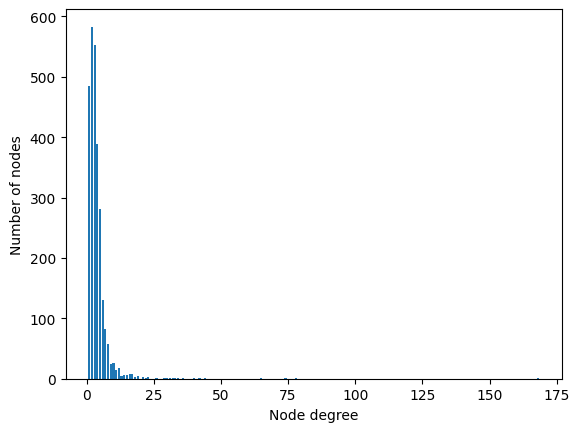

In [6]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import degree
from collections import Counter
import matplotlib.pyplot as plt

# Import dataset from PyTorch Geometric
dataset = Planetoid(root=".", name="Cora")
data = dataset[0]
#print(data)
# # Get list of degrees for each node
degrees = degree(data.edge_index[0]).numpy()

# # Count the number of nodes for each degree
numbers = Counter(degrees)



# Bar plot
fig, ax = plt.subplots()
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
plt.bar(numbers.keys(), numbers.values())

<BarContainer object of 233 artists>

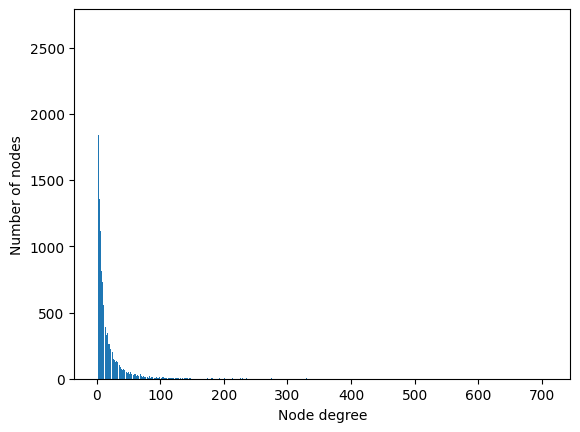

In [7]:
from torch_geometric.datasets import FacebookPagePage

# Import dataset from PyTorch Geometric
dataset = FacebookPagePage(root="Facebook")
data = dataset[0]

# Create masks
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

# Get list of degrees for each node
degrees = degree(data.edge_index[0]).numpy()

# Count the number of nodes for each degree
numbers = Counter(degrees)

# Bar plot
fig, ax = plt.subplots()
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
plt.bar(numbers.keys(), numbers.values())

These distributions look exponential with a heavy tail.
- Tail ranges from 1 neighbor (485 nodes) to 168 neighbors (1 node) for Cora dataset.
- Distribution even more skewed for Facebook dataset (tail ranges from 1 to 709).

These are exactly the kind of datasets where we want a **normalization process** to consider this disbalance.



In [8]:
import torch
torch.manual_seed(1)
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

dataset = Planetoid(root=".", name="Cora")
data = dataset[0]

# This function will be useful to calculate the accuracy score.
def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)


class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out): #three parameters as input: the number of input dimensions, the number of hidden dimensions and the number of output dimensions.
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)
        self.hidden_dimension = dim_h


    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

# Create the GCN model
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)

# Train
gcn.fit(data, epochs=100)

# Test
acc = gcn.test(data)
print(f'\nGCN test accuracy: {acc*100:.2f}%\n')

GCN(
  (gcn1): GCNConv(1433, 16)
  (gcn2): GCNConv(16, 7)
)
Epoch   0 | Train Loss: 1.932 | Train Acc: 15.71% | Val Loss: 1.94 | Val Acc: 15.20%
Epoch  20 | Train Loss: 0.099 | Train Acc: 100.00% | Val Loss: 0.75 | Val Acc: 77.80%
Epoch  40 | Train Loss: 0.014 | Train Acc: 100.00% | Val Loss: 0.72 | Val Acc: 77.20%
Epoch  60 | Train Loss: 0.015 | Train Acc: 100.00% | Val Loss: 0.71 | Val Acc: 77.80%
Epoch  80 | Train Loss: 0.017 | Train Acc: 100.00% | Val Loss: 0.71 | Val Acc: 77.00%
Epoch 100 | Train Loss: 0.016 | Train Acc: 100.00% | Val Loss: 0.71 | Val Acc: 76.40%

GCN test accuracy: 79.70%



In [9]:
# Load Facebook Page-Page
dataset = FacebookPagePage(root="Facebook")
data = dataset[0]
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

# Train GCN
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)
gcn.fit(data, epochs=100)
acc = gcn.test(data)
print(f'\nGCN test accuracy: {acc*100:.2f}%\n')

GCN(
  (gcn1): GCNConv(128, 16)
  (gcn2): GCNConv(16, 4)
)
Epoch   0 | Train Loss: 1.463 | Train Acc: 20.72% | Val Loss: 1.45 | Val Acc: 20.71%
Epoch  20 | Train Loss: 0.443 | Train Acc: 84.64% | Val Loss: 0.43 | Val Acc: 85.29%
Epoch  40 | Train Loss: 0.323 | Train Acc: 89.59% | Val Loss: 0.31 | Val Acc: 90.20%
Epoch  60 | Train Loss: 0.278 | Train Acc: 91.36% | Val Loss: 0.27 | Val Acc: 91.55%
Epoch  80 | Train Loss: 0.254 | Train Acc: 92.28% | Val Loss: 0.26 | Val Acc: 92.75%
Epoch 100 | Train Loss: 0.238 | Train Acc: 92.82% | Val Loss: 0.25 | Val Acc: 92.75%

GCN test accuracy: 91.70%



## TODO*
- Tune the model to see if you can improve it.
    - what are the hyperparameters you can play with ? 
- Report and Discuss the results against other baselines you already considered (linear graph layer, MLP, etc.)


In [10]:
class LinearGraphLayer(torch.nn.Module):
    """A simple linear graph layer similar to GCNConv but without aggregation"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, out_features)

    def forward(self, x, edge_index=None):
        # edge_index is ignored in this simple linear layer
        return self.linear(x)


class MLP(torch.nn.Module):
    """Multi-Layer Perceptron for node classification"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.layer1 = LinearGraphLayer(dim_in, dim_h)
        self.layer2 = LinearGraphLayer(dim_h, dim_out)
        self.hidden_dimension = dim_h

    def forward(self, x, edge_index=None):
        h = self.layer1(x)
        h = torch.relu(h)
        h = self.layer2(h)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs=200):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                           data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                   data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [11]:
import pandas as pd

dimsh = [2,4,8,16,32]
df_accs = pd.DataFrame(columns=['model','dimh', 'accuracy'])
all_gcns = [ GCN(dataset.num_features, dimh, dataset.num_classes) for dimh in dimsh ]
all_mlp = [ MLP(dataset.num_features, dimh, dataset.num_classes) for dimh in dimsh ]
all_models = [("GCN",all_gcns),("MLP",all_mlp)]
for name,list_model in all_models:
    for model in list_model:
        model.fit(data, epochs=100)
        acc = model.test(data)
        print(f'{name} with {model.hidden_dimension} hidden dimension has a test accuracy of {acc*100:.2f}  %\n')
        df_accs.loc[len(df_accs)] = [name,model.hidden_dimension,acc*100]


Epoch   0 | Train Loss: 1.481 | Train Acc: 21.25% | Val Loss: 1.48 | Val Acc: 22.11%
Epoch  20 | Train Loss: 0.996 | Train Acc: 61.09% | Val Loss: 1.01 | Val Acc: 59.78%
Epoch  40 | Train Loss: 0.811 | Train Acc: 72.05% | Val Loss: 0.82 | Val Acc: 71.44%
Epoch  60 | Train Loss: 0.694 | Train Acc: 76.55% | Val Loss: 0.70 | Val Acc: 75.44%
Epoch  80 | Train Loss: 0.632 | Train Acc: 77.85% | Val Loss: 0.64 | Val Acc: 76.79%
Epoch 100 | Train Loss: 0.595 | Train Acc: 78.38% | Val Loss: 0.60 | Val Acc: 77.49%
GCN with 2 hidden dimension has a test accuracy of 77.48  %

Epoch   0 | Train Loss: 1.517 | Train Acc: 33.14% | Val Loss: 1.51 | Val Acc: 32.32%
Epoch  20 | Train Loss: 0.871 | Train Acc: 70.24% | Val Loss: 0.88 | Val Acc: 69.18%
Epoch  40 | Train Loss: 0.598 | Train Acc: 76.09% | Val Loss: 0.60 | Val Acc: 75.74%
Epoch  60 | Train Loss: 0.493 | Train Acc: 79.48% | Val Loss: 0.50 | Val Acc: 79.24%
Epoch  80 | Train Loss: 0.436 | Train Acc: 85.34% | Val Loss: 0.43 | Val Acc: 85.64%
Epoc

In [12]:
display(df_accs)

,model,dimh,accuracy
0,GCN,2,tensor(77.4808)
1,GCN,4,tensor(85.9457)
2,GCN,8,tensor(90.4415)
3,GCN,16,tensor(91.9806)
4,GCN,32,tensor(92.3046)
5,MLP,2,tensor(68.7323)
6,MLP,4,tensor(74.8076)
7,MLP,8,tensor(75.4962)
8,MLP,16,tensor(75.4151)
9,MLP,32,tensor(74.7671)


MLP possess accuracy far below GCN , because GCN use normalisation it is better

# Predicting Web Traffic 
## #NodeRegression
We will try to predict a continuous value instead of a categorical variable for each node.
The dataset we will use is the Wikipedia Network (GNU General Public License v3.0), introduced
by Rozemberckzi et al. in 2019. It is composed of three page-page networks: chameleons (2,277
nodes and 31,421 edges), crocodiles (11,631 nodes and 170,918 edges), and squirrels (5,201 nodes and
198,493 edges). In these datasets, nodes represent articles and edges are mutual links between them.
Node features reflect the presence of particular words in the articles. Finally, the goal is to predict the
log average monthly traffic of December 2018.
We will apply a GCN to predict this traffic on the chameleon dataset.

In [13]:
from torch_geometric.datasets import WikipediaNetwork
import torch_geometric.transforms as T

dataset = WikipediaNetwork(root=".", name="chameleon", transform = T.RandomNodeSplit(num_val=200, num_test=500))
data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of unique features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: WikipediaNetwork()
-------------------
Number of graphs: 1
Number of nodes: 2277
Number of unique features: 2325
Number of classes: 5

Graph:
------
Edges are directed: True
Graph has isolated nodes: False
Graph has loops: True


In [14]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

url = 'https://snap.stanford.edu/data/wikipedia.zip'
with urlopen(url) as zurl:
    with ZipFile(BytesIO(zurl.read())) as zfile:
        zfile.extractall('.')

In [15]:
import pandas as pd

df = pd.read_csv('wikipedia/chameleon/musae_chameleon_target.csv')
values = np.log10(df['target'])
data.y = torch.tensor(values, dtype=torch.float32)
data.y

tensor([2.2330, 3.9079, 3.9329,  ..., 1.9956, 4.3598, 2.4409])

<BarContainer object of 63 artists>

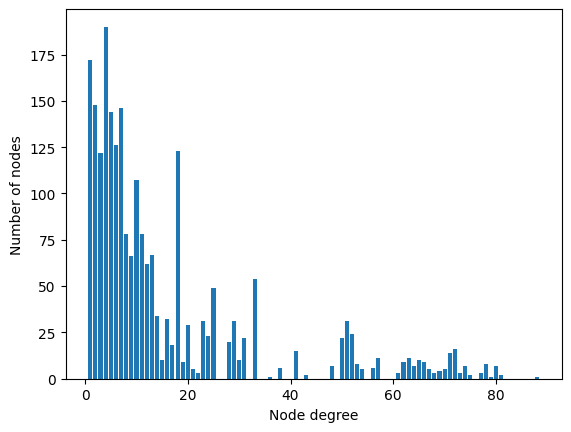

In [16]:
from torch_geometric.utils import degree
from collections import Counter

# Get list of degrees for each node
degrees = degree(data.edge_index[0]).numpy()

# Count the number of nodes for each degree
numbers = Counter(degrees)

# Bar plot
fig, ax = plt.subplots()
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
plt.bar(numbers.keys(), numbers.values())

/tmp/ipykernel_21229/2660044443.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(df['target'], fit=norm)


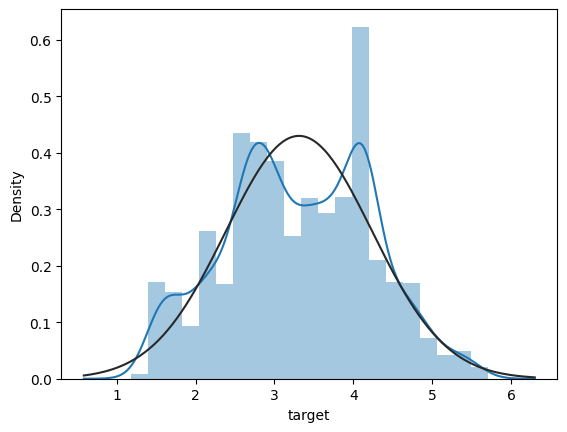

In [17]:
import seaborn as sns
from scipy.stats import norm

df['target'] = values
fig = sns.distplot(df['target'], fit=norm)

## TODO*
- Build  a model with 3 convolution layers and 1 linear layer
- Tune this model by playing with the sizes of the latent spaces and `dropout` function, as well as the number of layers.
- Compare the results against a "naive" GNN (i.e., with liner graph layer).
- Discuss your results.

In [18]:
class GCN3conv(torch.nn.Module):
    def __init__(self, in_channels, hidden1, hidden2, hidden3, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        self.conv3 = GCNConv(hidden2, hidden3)
        self.conv4 = torch.nn.Linear(hidden3, 1)
        self.dropout = dropout


    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.dropout(x, p=self.dropout, train=self.training)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = torch.dropout(x, p=self.dropout, train=self.training)

        x = self.conv3(x, edge_index)
        x = torch.relu(x)

        x = self.conv4(x)

        return x.squeeze()
    
    def fit(self, data, epochs=200):
        criterion = torch.nn.MSELoss() 
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f}')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        criterion = torch.nn.MSELoss()
        test_loss = criterion(out[data.test_mask], data.y[data.test_mask])
        return test_loss


In [19]:
class NaiveGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden1, hidden2, hidden3, dropout=0.3):
        super().__init__()
        
        self.layer1 = LinearGraphLayer(in_channels, hidden1)
        self.layer2 = LinearGraphLayer(hidden1, hidden2)
        self.layer3 = LinearGraphLayer(hidden2, hidden3)
        self.out_layer = torch.nn.Linear(hidden3, 1)
        
        self.dropout = dropout


    def forward(self, x, edge_index):
        x = self.layer1(x, edge_index)
        x = torch.relu(x)
        x = torch.dropout(x, p=self.dropout, train=self.training)

        x = self.layer2(x, edge_index)
        x = torch.relu(x)
        x = torch.dropout(x, p=self.dropout, train=self.training)

        x = self.layer3(x, edge_index)
        x = torch.relu(x)

        x = self.out_layer(x)
        return x.squeeze()

    def fit(self, data, epochs=200):
        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f}")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        criterion = torch.nn.MSELoss()
        test_loss = criterion(out[data.test_mask], data.y[data.test_mask])
        return test_loss

In [20]:
NaiveGCN_model = NaiveGCN(dataset.num_features, 16, 16,16)
NaiveGCN_model.fit(data, epochs=100)
acc = NaiveGCN_model.test(data)
print(f'NaiveGCN has a test accuracy of {acc*100:.2f}  %\n')
df_accs.loc[len(df_accs)] = ["NaiveGCN",(16 , 16 , 16),acc*100]


GCN3conv_model = GCN3conv(dataset.num_features, 16, 16, 16)
GCN3conv_model.fit(data, epochs=100)
acc = GCN3conv_model.test(data)
print(f'GCN3conv has a test accuracy of {acc*100:.2f}  %\n')
df_accs.loc[len(df_accs)] = ["GCN3conv",(16 , 16 , 16),acc*100]


Epoch   0 | Train Loss: 11.8196 | Val Loss: 12.7591
Epoch  20 | Train Loss: 2.7781 | Val Loss: 2.7048
Epoch  40 | Train Loss: 0.7188 | Val Loss: 1.0770
Epoch  60 | Train Loss: 0.4587 | Val Loss: 0.6797
Epoch  80 | Train Loss: 0.3348 | Val Loss: 0.9203
Epoch 100 | Train Loss: 0.2798 | Val Loss: 0.6327
NaiveGCN has a test accuracy of 65.12  %

Epoch   0 | Train Loss: 11.5641 | Val Loss: 12.4648
Epoch  20 | Train Loss: 3.5169 | Val Loss: 4.6927
Epoch  40 | Train Loss: 1.0846 | Val Loss: 1.8835
Epoch  60 | Train Loss: 0.5185 | Val Loss: 0.9473
Epoch  80 | Train Loss: 0.4299 | Val Loss: 0.8644
Epoch 100 | Train Loss: 0.4036 | Val Loss: 0.8221
GCN3conv has a test accuracy of 78.85  %



In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

out = gcn(data.x, data.edge_index)
y_pred = out.squeeze()[data.test_mask].detach().numpy()
mse = mean_squared_error(data.y[data.test_mask], y_pred)
mae = mean_absolute_error(data.y[data.test_mask], y_pred)

print('=' * 43)
print(f'MSE = {mse:.4f} | RMSE = {np.sqrt(mse):.4f} | MAE = {mae:.4f}')
print('=' * 43)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2277x2325 and 128x16)

[Text(0.5, 0, 'Ground truth'), Text(0, 0.5, 'Predicted values')]

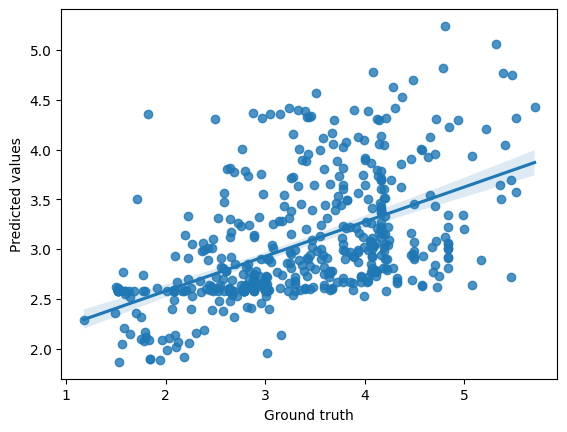

In [ ]:
fig = sns.regplot(x=data.y[data.test_mask].numpy(), y=y_pred)
fig.set(xlabel='Ground truth', ylabel='Predicted values')

# Studying latent representation

- Take a dataset designed for node classification
- Design an experimental protocol to study how the layers help to build a representation that group together nodes sharing the same class 
- tips: 
    - you can start from node features
    - you can use tsne, pacmap or just clustering ...
- Perform this experiment
    - vizualize and analyze the results
    - draw some conclusions